Table1 breast cancer patients:
   Unnamed: 0 Patient_ID  Age Stage ER PR HER2 Ki67  Survival_months  Status
0           0       P001   45     I  +  +    -  10%               70       0
1           1       P002   55    II  +  -    -  40%               50       0
2           2       P003   62    II  -  -    +  70%               45       1
3           3       P004   38     I  +  +    -  20%               50       0
4           4       P005   42    II  +  -    -  30%               30       1
5           5       P006   57   III  -  +    +  65%               45       1
6           6       P007   60   III  -  +    +  75%               35       1
7           7       P008   49     I  +  +    -  50%               20       1
8           8       P009   51    II  +  -    -  45%               40       0
9           9       P010   39     I  +  +    -  30%               60       0
-------------
Overall survival curve:


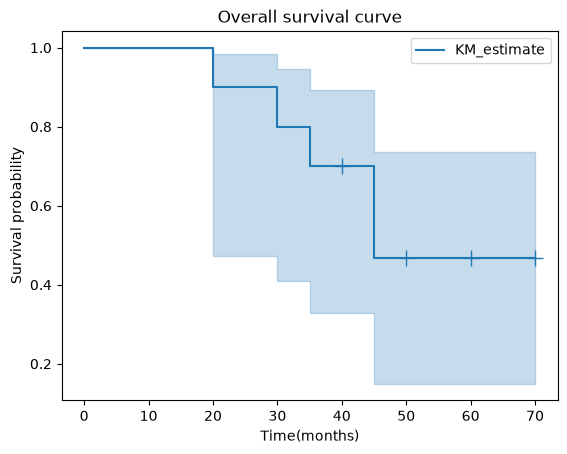

----------
Survival curves by stage:


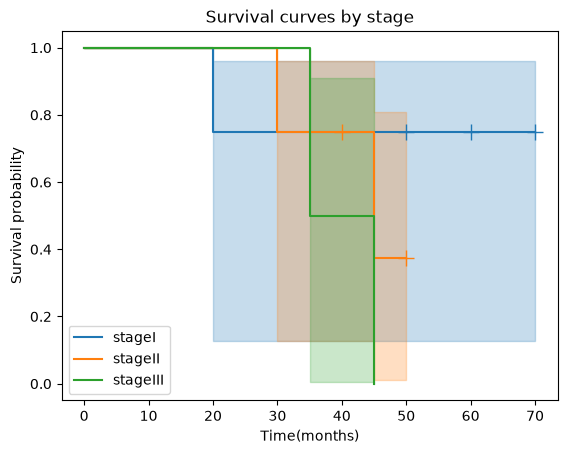

p value: 0.42136039096062616
因为P值大于0.05，所以分期的生存曲线没有统计学意义。
-------------
Survival curves by ER:


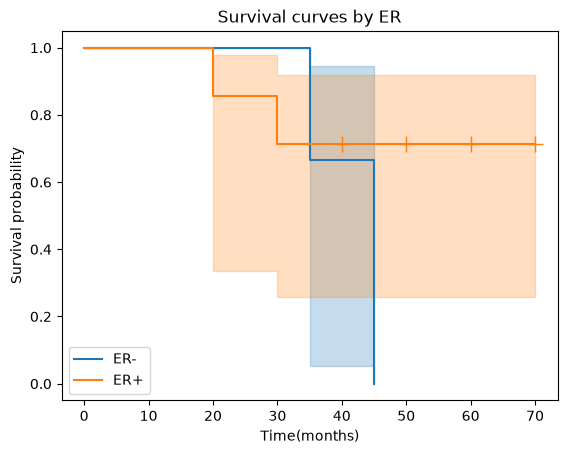

p value: 0.19000537623733096
因为P值大于0.05，所以关于ER的生存曲线没有统计学意义。
------------
Survival curves by Ki67:


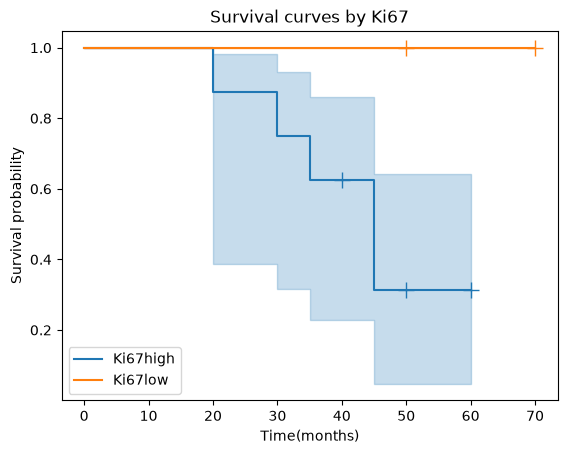

P value: 0.15254462500774932
因为P值大于0.05，所以Ki67的生存曲线没有统计学意义。


In [17]:
import pandas as pd 
df=pd.read_excel('breast cancer patients.xlsx')
print('Table1 breast cancer patients:')
print(df)
print('-------------')
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
kmf=KaplanMeierFitter()
print('Overall survival curve:')
kmf.fit(
    durations=df['Survival_months'],
    event_observed=df['Status']
)
kmf.plot(
    show_censors=True
)
plt.title('Overall survival curve')
plt.xlabel('Time(months)')
plt.ylabel('Survival probability')
plt.savefig(
    'Overall survival curve of breast cancer patients.png',
    dpi=300
)
plt.show()
print('----------')
print('Survival curves by stage:')
stages=['I','II','III']
for stage in stages:
    stage_data=df[df['Stage']==stage]
    kmf.fit(
        durations=stage_data['Survival_months'],
        event_observed=stage_data['Status'],
        label='stage'+stage
    )
    kmf.plot(
        show_censors=True
    )
plt.title('Survival curves by stage')
plt.xlabel('Time(months)')
plt.ylabel('Survival probability')
plt.legend()
plt.savefig(
    'Survival curves by stage.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
from lifelines.statistics import multivariate_logrank_test
result1=multivariate_logrank_test(
    df['Survival_months'],
    df['Stage'],
    df['Status']
)
print('p value:',result1.p_value)
print('因为P值大于0.05，所以分期的生存曲线没有统计学意义。')
print('-------------')
print('Survival curves by ER:')
for group in ['-','+']:
    ix=df['ER']==group
    kmf.fit(
        durations=df.loc[ix,'Survival_months'],
        event_observed=df.loc[ix,'Status'],
        label='ER'+group
    )
    kmf.plot(
        show_censors=True
    )
plt.title('Survival curves by ER')
plt.xlabel('Time(months)')
plt.ylabel('Survival probability')
plt.legend()
plt.savefig(
    'Survival curves by ER.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
from lifelines.statistics import logrank_test
group0=df[df['ER']=='-']
group1=df[df['ER']=='+']
result2=logrank_test(
    group0['Survival_months'],
    group1['Survival_months'],
    event_observed_A=group0['Status'],
    event_observed_B=group1['Status']
)
print('p value:',result2.p_value)
print('因为P值大于0.05，所以关于ER的生存曲线没有统计学意义。')
print('------------')
print('Survival curves by Ki67:')
df['Ki67_group']=df['Ki67'].apply(lambda x:'high' if x>='30%' else 'low')
for kgroup in ['high','low']:
    ix=df['Ki67_group']==kgroup
    kmf.fit(
        durations=df.loc[ix,'Survival_months'],
        event_observed=df.loc[ix,'Status'],
        label='Ki67'+kgroup
    )
    kmf.plot(
        show_censors=True
    )
plt.title('Survival curves by Ki67')
plt.xlabel('Time(months)')
plt.ylabel('Survival probability')
plt.legend()
plt.savefig(
    'Survival curves by Ki67.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
Kgroup0=df[df['Ki67_group']=='low']
Kgroup1=df[df['Ki67_group']=='high']
result2=logrank_test(
    Kgroup0['Survival_months'],
    Kgroup1['Survival_months'],
    event_observed_A=Kgroup0['Status'],
    event_observed_B=Kgroup1['Status']
)
print('P value:',result2.p_value)
print('因为P值大于0.05，所以Ki67的生存曲线没有统计学意义。')

    

